In [1]:
"""
Compare annualized return, volatility, Sharpe ratio, and max drawdown
for S&P 500 (SPY), Nasdaq-100 (QQQ), and the two largest bond ETFs (AGG, BND).

Requires: pip install yfinance pandas numpy
"""

import yfinance as yf
import pandas as pd
import numpy as np

# ---- Settings ----
TICKERS = ["SPY", "QQQ", "AGG", "BND"]
PERIOD = "max"          # pulls each ticker's full available history
RISK_FREE_RATE = 0.04   # annualized risk-free rate assumption (adjust as needed)

def get_prices(tickers, period):
    data = yf.download(tickers, period=period, auto_adjust=True)["Close"]
    return data

def compute_metrics(prices, risk_free_rate):
    results = {}
    inception = {}

    for ticker in prices.columns:
        # Use only this ticker's own valid history (each ETF started trading on a different date)
        series = prices[ticker].dropna()
        r = series.pct_change().dropna()

        inception[ticker] = series.index[0].date()

        # Annualized return (CAGR based on total growth over the period)
        total_growth = series.iloc[-1] / series.iloc[0]
        years = len(r) / 252
        cagr = total_growth ** (1 / years) - 1

        # Annualized volatility
        vol = r.std() * np.sqrt(252)

        # Sharpe ratio
        sharpe = (cagr - risk_free_rate) / vol

        # Max drawdown
        cum = (1 + r).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        max_dd = drawdown.min()

        # Average annualized return: mean of each calendar year's return (simple average, not compounded)
        yearly_returns = r.groupby(r.index.year).apply(lambda x: (1 + x).prod() - 1)
        avg_annual_return = yearly_returns.mean()

        # Average annualized std: mean of each calendar year's annualized volatility
        yearly_vol = r.groupby(r.index.year).std() * np.sqrt(252)
        avg_annual_vol = yearly_vol.mean()

        results[ticker] = {
            "Inception": inception[ticker],
            "Years": round(years, 1),
            "CAGR (%)": round(cagr * 100, 2),
            "Avg Annual Return (%)": round(avg_annual_return * 100, 2),
            "Volatility (%)": round(vol * 100, 2),
            "Avg Annual Std (%)": round(avg_annual_vol * 100, 2),
            "Sharpe Ratio": round(sharpe, 2),
            "Max Drawdown (%)": round(max_dd * 100, 2),
        }

    return pd.DataFrame(results).T

if __name__ == "__main__":
    prices = get_prices(TICKERS, PERIOD)
    metrics = compute_metrics(prices, RISK_FREE_RATE)
    print(f"\nMetrics over each ticker's full available history (risk-free rate assumed: {RISK_FREE_RATE*100:.1f}%)\n")
    print(metrics.to_string())

[*********************100%***********************]  4 of 4 completed


Metrics over each ticker's full available history (risk-free rate assumed: 4.0%)

      Inception Years CAGR (%) Avg Annual Return (%) Volatility (%) Avg Annual Std (%) Sharpe Ratio Max Drawdown (%)
AGG  2003-09-29  22.9     3.06                  3.02           5.17               4.64        -0.18           -18.43
BND  2007-04-10  19.4      3.0                  3.03           5.19               4.69        -0.19           -18.58
QQQ  1999-03-10  27.4    10.83                 15.03          26.92               24.1         0.25           -82.96
SPY  1993-01-29  33.5    10.89                 12.21          18.55              16.94         0.37           -55.19


[*********************100%***********************]  4 of 4 completed


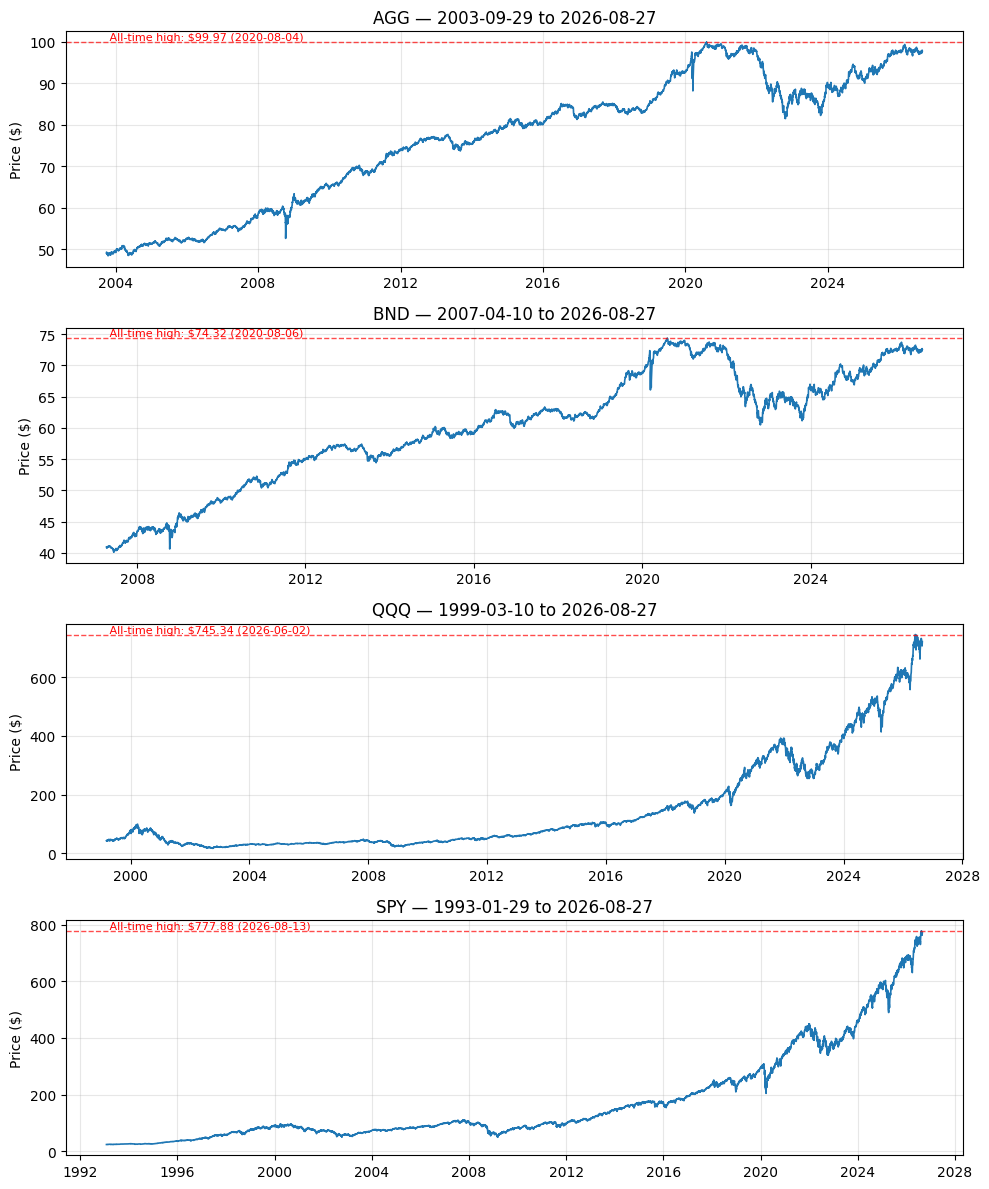

In [2]:
"""
Plot each ticker's price history from inception to today, as separate charts.

Requires: pip install yfinance pandas matplotlib
Run this after (or independently of) compare_etfs.py.
"""

import yfinance as yf
import matplotlib.pyplot as plt

TICKERS = ["SPY", "QQQ", "AGG", "BND"]

def get_prices(tickers):
    data = yf.download(tickers, period="max", auto_adjust=True)["Close"]
    return data

def plot_each(prices):
    fig, axes = plt.subplots(len(prices.columns), 1, figsize=(10, 12), sharex=False)

    for ax, ticker in zip(axes, prices.columns):
        series = prices[ticker].dropna()
        max_price = series.max()
        max_date = series.idxmax()

        ax.plot(series.index, series.values, linewidth=1.2)
        ax.axhline(max_price, color="red", linestyle="--", linewidth=1, alpha=0.7)
        ax.text(series.index[0], max_price, f" All-time high: ${max_price:.2f} ({max_date.date()})",
                color="red", va="bottom", fontsize=8)
        ax.set_title(f"{ticker} — {series.index[0].date()} to {series.index[-1].date()}")
        ax.set_ylabel("Price ($)")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("etf_price_history.png", dpi=150)
    plt.show()

if __name__ == "__main__":
    prices = get_prices(TICKERS)
    plot_each(prices)